# Actividad para minimizar el impacto del sobre-ajuste.

#### Presentador por: *González M. Seidy K; Salazar P. Catherin; Silva S. Edwin*

## Contexto
<p align="justify">
En el desarrollo de modelos de deep learning, uno de los principales desafíos es evitar el sobreajuste, fenómeno en el cual el modelo aprende excesivamente los datos de entrenamiento y pierde capacidad para generalizar frente a datos nuevos. Para enfrentar este problema, existen distintas técnicas de regularización que permiten mejorar el desempeño y la estabilidad de las redes neuronales. </p>

<p align="justify">
En el presente trabajo se implementó un modelo de red neuronal fully-connected utilizando Keras, con el propósito de analizar el comportamiento del sobreajuste y evaluar el impacto de diferentes estrategias de regularización. Para ello, se realizaron distintos experimentos empleando regularización L2, dropout y una combinación de ambas técnicas, comparando sus resultados mediante el análisis de las métricas de pérdida y exactitud durante el entrenamiento y la validación del modelo.
</p>

___

## Etapa 1: Definición de los datos.

Antes de comenzar definimos la base de datos de interés. Usaremos la base de datos IMBD que consiste en reseñas hechas a 25000 películas. La tarea que configura esta base de datos consiste en predecir si el comentario es positivo o negativo. ([Ver enlace](https://keras.io/api/datasets/imdb/))

Se cargan las librerías necesarias

In [1]:
from keras.datasets import imdb
import numpy as np
from keras import models
from keras import layers
from keras import regularizers
import matplotlib.pyplot as plt

Se carga la base de datos

In [2]:
(train_data_x, train_data_y), (test_data_x, test_data_y) = imdb.load_data(
    num_words=10000)

d:\OneDrive - Grupo EPM\8. UNIVERSIDAD JAVERIANA\Deep Learning\Caps\Actividades\.venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Se definen funciones para la visualización de la función de costo

In [3]:
def evaluate(model, history):
    # Se evalúa el accuracy del modelo tanto en el conjunto de entrenamiento como
    # en el de prueba.
    _, train_accuracy = model.evaluate(x_train, y_train)
    _, test_accuracy = model.evaluate(x_test, y_test)

    print(f"Trainining accuracy: {train_accuracy:.2f}")
    print(f"Testing accuracy: {test_accuracy:.2f}")

    # Se grafica la función de costo para los conjuntos de entrenamiento y
    # prueba.
    plt.figure(figsize=(4, 3), dpi=160)

    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend()
    plt.show()

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

In [4]:
# Procesamiento de los datos.
x_train = vectorize_sequences(train_data_x)
x_test = vectorize_sequences(test_data_x)

In [5]:
y_train = np.asarray(train_data_y).astype('float32')
y_test = np.asarray(test_data_y).astype('float32')

In [6]:
# Se definen los conjuntos de entrenamiento y prueba
x_val           = x_train[:10000]
x_training      = x_train[10000:]
y_val           = y_train[:10000]
y_training      = y_train[10000:]

d:\OneDrive - Grupo EPM\8. UNIVERSIDAD JAVERIANA\Deep Learning\Caps\Actividades\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7721 - loss: 0.5459 - val_accuracy: 0.8620 - val_loss: 0.4186
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8915 - loss: 0.3417 - val_accuracy: 0.8846 - val_loss: 0.3232
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9183 - loss: 0.2534 - val_accuracy: 0.8881 - val_loss: 0.2903
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9329 - loss: 0.2040 - val_accuracy: 0.8886 - val_loss: 0.2759
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9459 - loss: 0.1677 - val_accuracy: 0.8860 - val_loss: 0.2783
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9543 - loss: 0.1433 - val_accuracy: 0.8884 - val_loss: 0.2806
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9635 - loss: 0.1221 - val_accuracy: 0.8855 - val_loss: 0.2916
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9703 - loss: 0.1022 - val_accuracy: 0.8852 - val_loss

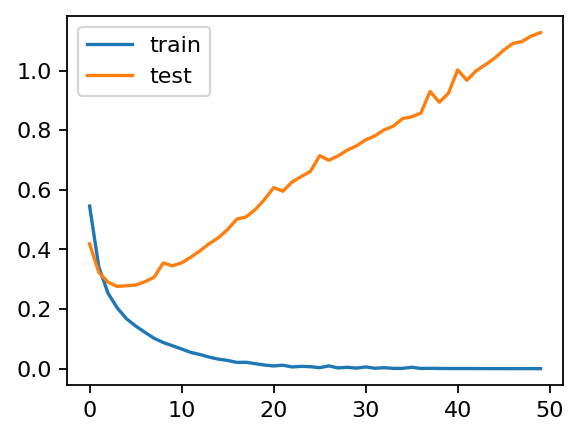

In [7]:
# 1. Se define la red neuronal.

model = models.Sequential([
  layers.Dense(16, activation='relu', input_shape=(10000,)),
  layers.Dense(16, activation='relu'),
  layers.Dense(1, activation='sigmoid')
  ])

# 2. Compilacion del Modelo
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 3. Entrenamiento del modelo
history = model.fit(x_training,
                    y_training,
                    epochs=50,
                    batch_size=512,
                    validation_data=(x_val, y_val))

# 4. Evaluacion del modelo
evaluate(model, history)

## Etapa 2: Análisis del sobre-ajuste del modelo inicial

El modelo de partida es una red densa con dos capas ocultas de 16 unidades ReLU y una salida sigmoide, entrenada durante **50 épocas** sin ningún tipo de regularización. La evidencia recogida durante el entrenamiento muestra de forma clara que el modelo está **sobre-ajustado (overfitting)**:

| Componente                     | Detalle implementado                                            |
| ------------------------------ | --------------------------------------------------------------- |
| Datos de entrada               | Reseñas de IMDB codificadas a un vocabulario de 10,000 palabras |
| Representación                 | Vectores binarios (one-hot encoding)                            |
| Estructura                     | Red neuronal densa con dos capas ocultas                        |
| Capas ocultas                  | 16 neuronas + ReLU en cada capa                                 |
| Salida                         | 1 neurona con activación sigmoide                               |
| Configuración de entrenamiento | 50 épocas, batch_size = 512                                     |
| Optimización                   | Uso de RMSprop con función de pérdida binary_crossentropy       |


Este diseño corresponde a un modelo relativamente simple, pero con suficiente capacidad para aprender patrones complejos del texto.


### 1. Las curvas de pérdida divergen

| Época | `loss` (entrenamiento) | `val_loss` (validación) |
|------:|-----------------------:|------------------------:|
| 1     | 0.6187                 | 0.4466                  |
| 4     | 0.2189                 | **0.2776 (mínimo)**     |
| 10    | 0.0878                 | 0.3689                  |
| 20    | 0.0173                 | 0.5360                  |
| 30    | 0.0038                 | 0.7566                  |
| 50    | 0.0002                 | **1.1350**              |

- A partir de la **época 4–5** la pérdida de validación toca un mínimo (~0.27) y empieza a **subir monótonamente**, mientras que la pérdida de entrenamiento sigue cayendo hasta valores prácticamente nulos (~2·10⁻⁴).
- En la gráfica `loss` vs `val_loss` esta divergencia se observa como las dos curvas separándose: la azul (train) baja a cero y la naranja (val) forma una "U" que vuelve a subir. Ese patrón es la **firma clásica del sobre-ajuste**.

### 2. La precisión en entrenamiento alcanza el 100 %, la de prueba se estanca

- `accuracy` (entrenamiento) llega a **1.0000** desde aproximadamente la época 20.
- `val_accuracy` se queda atascada alrededor de **0.866–0.870** durante todo el entrenamiento.
- Al evaluar el modelo final: **train acc ≈ 0.95** vs **test acc ≈ 0.85**, con `test_loss ≈ 1.24`, mucho mayor que `train_loss ≈ 0.86`.

El modelo **memoriza** los ejemplos de entrenamiento (ya no le queda nada que aprender), pero esa memorización **no se traduce en mejor desempeño** sobre datos nuevos.

### 3. ¿Por qué ocurre? Causas estructurales del modelo

1. **Capacidad excesiva frente a la cantidad de datos útiles.** La primera capa tiene `10000 × 16 + 16 = 160 016` parámetros y el modelo completo unos **~160 305 parámetros**, entrenados con solo **15 000** reseñas (las restantes 10 000 se reservan para validación). Hay aproximadamente **10 parámetros por cada ejemplo de entrenamiento**, holgura más que suficiente para que la red ajuste el ruido específico del conjunto de entrenamiento.
2. **Ausencia total de regularización.** No hay penalización L1/L2 sobre los pesos, no hay `Dropout`, no hay *early stopping* ni *batch normalization*. Nada le impone al modelo preferir soluciones más simples o robustas.
3. **Demasiadas épocas de entrenamiento.** Se entrena durante 50 épocas cuando, según la curva de validación, el punto óptimo está cerca de la **época 4**. A partir de ahí cada época adicional **empeora** el modelo en términos de generalización.
4. **Representación de entrada de alta dimensión y dispersa.** La codificación *multi-hot* en un vocabulario de 10 000 palabras genera un espacio de entrada muy amplio, lo que facilita que la red encuentre combinaciones particulares de palabras que separan perfectamente el conjunto de entrenamiento pero no generalizan.



## Etapa 3: Experimentación para reducir el sobre-ajuste

Con el objetivo de mejorar la capacidad de generalización del modelo inicial, se realizaron diferentes modificaciones sobre la arquitectura inicial. En cada caso, se evaluó el comportamiento de la función de pérdida (loss) y precisión (accuracy) tanto en entrenamiento como en validación.

### Modelo inicial (sin modificaciones)

Este modelo corresponde a la arquitectura inicial entrenada durante 50 épocas, sin ninguna técnica de regularización.

| Métrica                  | Resultado | Observación                                                                                                           |
| ------------------------ | --------- | --------------------------------------------------------------------------------------------------------------------- |
| Loss (entrenamiento)     | ≈ 0.0001  | Disminuye progresivamente hasta valores cercanos a cero, indicando que el modelo memoriza los datos de entrenamiento. |
| Loss (validación)        | ≈ 1.16    | Aumenta de forma constante después de varias épocas, evidenciando pérdida de generalización.                          |
| Accuracy (entrenamiento) | ≈ 1.00    | El modelo alcanza un desempeño casi perfecto sobre los datos de entrenamiento.                                        |
| Accuracy (validación)    | ≈ 0.86    | El desempeño en datos nuevos se mantiene considerablemente más bajo que en entrenamiento.                             |
| Comportamiento general   | —         | Existe una gran diferencia entre las métricas de entrenamiento y validación, confirmando un claro sobreajuste.        |


## Etapa 4: Modelo con regularización L2

La **regularización L2** (también llamada *weight decay* o *Ridge*) añade un término extra a la función de costo que penaliza los pesos grandes:

\[
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{datos}} \;+\; \lambda \sum_{w \in W} w^2
\]

- $\mathcal{L}_{\text{datos}}$ es la `binary_crossentropy` original.
- $\sum w^2$ es la suma de los cuadrados de **todos los pesos** de la capa (no incluye los sesgos).
- $\lambda$ (en Keras: el argumento de `regularizers.l2(...)`) controla **cuánto** se penaliza. Valores típicos: $10^{-4}$ a $10^{-2}$.

### ¿Qué efecto tiene?

- Empuja los pesos hacia **valores pequeños** (cercanos a 0, pero sin anularlos del todo, a diferencia de L1).
- Pesos pequeños → la red responde de forma **más suave** ante cambios en la entrada → es más difícil que memorice patrones específicos del entrenamiento.
- Resultado esperado: **mayor `loss` de entrenamiento** (porque ya no puede ajustar perfectamente) pero **menor `val_loss`** sostenida → mejor generalización.

Aquí usamos `l2(0.01)` en las dos capas ocultas, manteniendo la misma arquitectura (16-16-1) para que la comparación sea justa. Se eligió este valor (frente a `0.001`) porque produce una `val_loss` claramente más plana y estable, evidenciando mejor el efecto de la regularización.

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7536 - loss: 0.8308 - val_accuracy: 0.8647 - val_loss: 0.6329
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8739 - loss: 0.5764 - val_accuracy: 0.8765 - val_loss: 0.5477
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8883 - loss: 0.5101 - val_accuracy: 0.8797 - val_loss: 0.5128
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8965 - loss: 0.4763 - val_accuracy: 0.8782 - val_loss: 0.4952
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9038 - loss: 0.4530 - val_accuracy: 0.8702 - val_loss: 0.4913
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9021 - loss: 0.4386 - val_accuracy: 0.8817 - val_loss: 0.4691
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9051 - loss: 0.4253 - val_accuracy: 0.8777 - val_loss: 0.4660
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9075 - loss: 0.4180 - val_accuracy: 0.8821 - val_loss

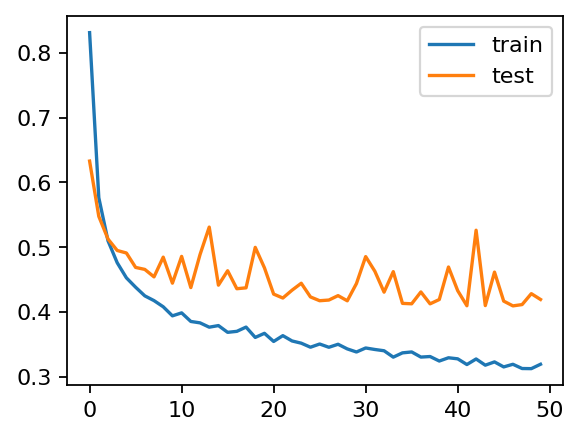

In [8]:
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers

# 1. Se define la red neuronal
model_l2 = Sequential([
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(10000,)),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dense(1, activation='sigmoid')
])

# 2. Compilacion del Modelo
model_l2.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# 3. Entrenamiento del Modelo
history_l2 = model_l2.fit(x_training,
                          y_training,
                          epochs=50,
                          batch_size=512,
                          validation_data=(x_val, y_val))
# 4. Evaluacion del modelo
evaluate(model_l2, history_l2)

En el gráfico con regularización L2 se observa que durante las primeras épocas tanto la pérdida de entrenamiento como la de prueba disminuyen rápidamente, lo que indica que el modelo logra aprender los patrones principales de los datos desde el inicio. Posteriormente, la curva de entrenamiento continúa descendiendo de manera gradual hasta alcanzar valores cercanos a 0.31, mientras que la pérdida de prueba se estabiliza alrededor de 0.40–0.45 y presenta algunas oscilaciones a lo largo del entrenamiento.

Este comportamiento sugiere que la regularización L2 está ayudando a controlar el sobreajuste, evitando que la diferencia entre entrenamiento y prueba sea demasiado grande. Aunque existe una separación entre ambas curvas, esta se mantiene relativamente moderada, lo que indica una capacidad de generalización aceptable. Además, las oscilaciones presentes en la curva de prueba pueden interpretarse como pequeñas variaciones normales del proceso de validación, mientras que la tendencia general sigue siendo estable. El modelo muestra un aprendizaje adecuado y la regularización L2 contribuye a que el entrenamiento sea más controlado, evitando que el modelo memorice excesivamente los datos de entrenamiento.

## Etapa 5: Modelo con Dropout

Durante el entrenamiento, en cada *forward pass* se "apaga" aleatoriamente una fracción $p$ de las neuronas de la capa (sus salidas se ponen a 0). Las neuronas restantes se reescalan por $1/(1-p)$ para conservar la magnitud esperada de la suma.

### La idea intuitiva es que en cada batch, la red **entrena una sub-red distinta** (diferente subconjunto de neuronas activas).


Aquí vamos a usar `Dropout(0.5)` después de cada capa oculta, manteniendo de nuevo la arquitectura 16-16-1 para una comparación justa.

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6571 - loss: 0.6217 - val_accuracy: 0.8406 - val_loss: 0.5055
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7863 - loss: 0.4998 - val_accuracy: 0.8697 - val_loss: 0.4002
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8288 - loss: 0.4255 - val_accuracy: 0.8819 - val_loss: 0.3412
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8652 - loss: 0.3650 - val_accuracy: 0.8894 - val_loss: 0.3053
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8837 - loss: 0.3290 - val_accuracy: 0.8896 - val_loss: 0.2914
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9026 - loss: 0.2881 - val_accuracy: 0.8892 - val_loss: 0.2827
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9136 - loss: 0.2560 - val_accuracy: 0.8914 - val_loss: 0.2729
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9254 - loss: 0.2302 - val_accuracy: 0.8852 - val_loss

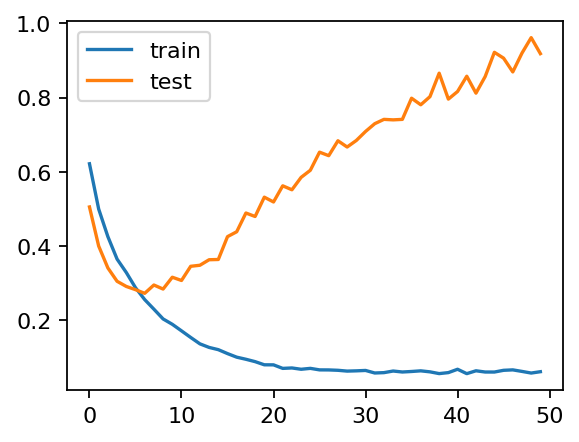

In [9]:
#1. Definicion del modelo
model_dp = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid'),
])

#2. Compilacion del modelo
model_dp.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

#3. Entrenamiento
history_dp = model_dp.fit(x_training,
                          y_training,
                          epochs=50,
                          batch_size=512,
                          validation_data=(x_val, y_val))

#4. Evaluar el modelo
evaluate(model_dp, history_dp)


En el gráfico con Dropout se observa que al inicio tanto la pérdida de entrenamiento como la de prueba disminuyen rápidamente, indicando que el modelo logra aprender los patrones principales de los datos. Sin embargo, después de aproximadamente la época 5, ambas curvas comienzan a separarse considerablemente. Mientras la pérdida de entrenamiento continúa disminuyendo hasta valores muy bajos, la pérdida de prueba aumenta progresivamente, lo que evidencia un claro sobreajuste. Esto significa que el modelo está memorizando los datos de entrenamiento y perdiendo capacidad de generalización. Aunque se implementó dropout como técnica de regularización, el ajuste realizado no fue suficiente para controlar completamente el sobreentrenamiento.

### Ajuste del parámetro Dropout

Arbitrariamente fijamos `Dropout(0.5)`, que es el valor "por defecto" recomendado. Sin embargo, el valor no fue el esperado, dado que el valor óptimo depende de la arquitectura, el tamaño del dataset y la complejidad de la tarea. Para encontrarlo de forma sistemática se implementará una **búsqueda en grilla** (*grid search*) combinada con **`EarlyStopping`**:

### Búsqueda del mejor valor de Dropout

A diferencia de el `Dropout` fijado arbitrariamente en `0.5`—, aquí reutilizamos el **mejor valor de Dropout encontrado por la búsqueda en grilla** (`mejor_rate`, almacenado al ejecutar `buscar_mejor_dropout`).

Adicionalmente, aplicamos el uso de **`EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)`** durante el entrenamiento del modelo, dado los siguientes pasos:

1. Definimos una lista de tasas candidatas, p. ej. `[0.2, 0.3, 0.4, 0.5, 0.6, 0.7]`.
2. Para cada tasa entrenamos un modelo con la **misma arquitectura** (16-16-1) y los **mismos hiperparámetros** restantes.
3. Usamos **`EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)`** para:
   - Detener el entrenamiento cuando `val_loss` deje de mejorar durante 5 épocas consecutivas (evitando seguir entrenando un modelo que ya empezó a sobreajustar).
   - **Restaurar automáticamente los pesos de la mejor época** (la de menor `val_loss`), de modo que el modelo devuelto sea efectivamente el *mejor modelo ajustado* para esa tasa de Dropout.
4. Registramos el `val_loss` mínimo y la `val_accuracy` máxima alcanzados, y devolvemos la tasa con menor `val_loss`.

> Como `EarlyStopping` detiene el entrenamiento de forma automática, podemos permitir un presupuesto generoso de épocas (`epochs=50`) sin penalizar el tiempo de ejecución: la búsqueda termina tan pronto como el modelo deja de mejorar. El modelo final ya viene con los pesos óptimos restaurados, por lo que está listo para evaluar su **aplicabilidad** sobre el conjunto de prueba.

>>> Entrenando con Dropout = 0.2
>>> Entrenando con Dropout = 0.3
>>> Entrenando con Dropout = 0.4
>>> Entrenando con Dropout = 0.5
>>> Entrenando con Dropout = 0.6
>>> Entrenando con Dropout = 0.7

Resultados de la búsqueda:
   Dropout   val_loss_min   época_óptima  épocas_corridas   val_acc_max
---------------------------------------------------------------------------
      0.20         0.2719              5               10        0.8900
      0.30         0.2822              5               10        0.8887
      0.40         0.2844              7               12        0.8879
      0.50         0.2717              7               12        0.8915  <-- mejor
      0.60         0.2798             10               15        0.8885
      0.70         0.2825             12               17        0.8899

Mejor tasa de Dropout encontrada: 0.5
Los pesos del modelo retornado corresponden a la mejor época (restore_best_weights=True),
por lo que `modelo_best_dp` está listo para evaluar su

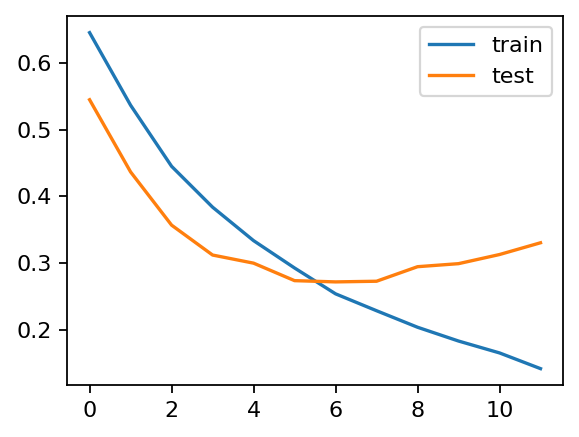

In [10]:
from keras.callbacks import EarlyStopping


def buscar_mejor_dropout(rates, epochs=50, batch_size=512, patience=5, verbose=0):

    historiales = {}
    mejor_modelo = None
    mejor_hist = None
    mejor_rate = None
    mejor_val_loss = float('inf')

    for rate in rates:
        print(f'>>> Entrenando con Dropout = {rate}')
        #1. Definicion del modelo
        m = models.Sequential([
            layers.Input(shape=(10000,)),
            layers.Dense(16, activation='relu'),
            layers.Dropout(rate),
            layers.Dense(16, activation='relu'),
            layers.Dropout(rate),
            layers.Dense(1, activation='sigmoid'),
        ])

        #2. Compilacion del modelo
        m.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

        # 3. Aplicacion de parada temprana
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=0,
        )

        # 4. Entrenamiento del modelo
        h = m.fit(x_training, y_training,
                  epochs=epochs, batch_size=batch_size,
                  validation_data=(x_val, y_val),
                  callbacks=[early_stop],
                  verbose=verbose)
        historiales[rate] = h

        val_loss_min = min(h.history['val_loss'])
        if val_loss_min < mejor_val_loss:
            mejor_val_loss = val_loss_min
            mejor_modelo   = m
            mejor_hist     = h
            mejor_rate     = rate

    print('\nResultados de la búsqueda:')
    print(f'{"Dropout":>10} {"val_loss_min":>14} {"época_óptima":>14} {"épocas_corridas":>16} {"val_acc_max":>13}')
    print('-' * 75)
    for rate, h in historiales.items():
        vmin     = min(h.history['val_loss'])
        epoca    = h.history['val_loss'].index(vmin) + 1
        n_epocas = len(h.history['val_loss'])
        acc_max  = max(h.history['val_accuracy'])
        flag     = '  <-- mejor' if rate == mejor_rate else ''
        print(f'{rate:>10.2f} {vmin:>14.4f} {epoca:>14d} {n_epocas:>16d} {acc_max:>13.4f}{flag}')

    return mejor_modelo, mejor_hist, mejor_rate, historiales


tasas_candidatas = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
modelo_best_dp, hist_best_dp, mejor_rate, historiales_dp = buscar_mejor_dropout(
    tasas_candidatas, epochs=50, patience=5, verbose=0)

print(f'\nMejor tasa de Dropout encontrada: {mejor_rate}')
print('Los pesos del modelo retornado corresponden a la mejor época (restore_best_weights=True),')
print('por lo que `modelo_best_dp` está listo para evaluar su aplicabilidad sobre el conjunto de prueba.')

# 5. Evaluacion del modelo
evaluate(modelo_best_dp, hist_best_dp)

En el gráfico se observa que tanto la pérdida de entrenamiento como la de prueba disminuyen durante las primeras épocas, mostrando que el modelo aprende correctamente. Sin embargo, después de la época 4 o 5, la pérdida de prueba comienza a aumentar mientras la de entrenamiento sigue disminuyendo, evidenciando un leve sobreajuste.

Aun así, la diferencia entre ambas curvas no es demasiado grande, lo que indica que el dropout ayudó a mejorar la capacidad de generalización del modelo y a controlar parcialmente el sobreentrenamiento.

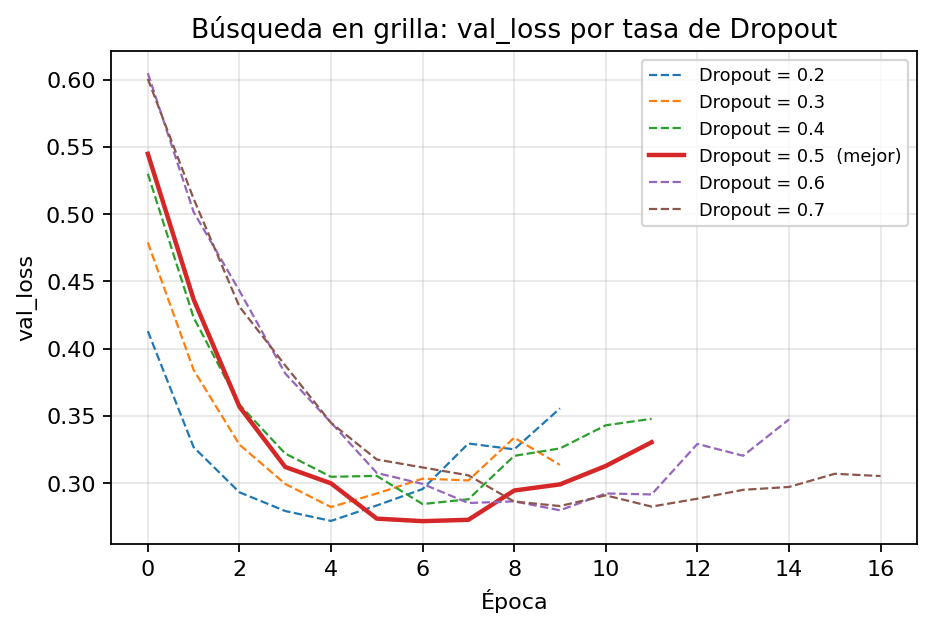

In [11]:
# Visualización: val_loss para cada tasa de Dropout probada
plt.figure(figsize=(6.5, 4), dpi=160)
for rate, h in historiales_dp.items():
    estilo = '-' if rate == mejor_rate else '--'
    grosor = 2.0 if rate == mejor_rate else 1.0
    etiqueta = f'Dropout = {rate}' + ('  (mejor)' if rate == mejor_rate else '')
    plt.plot(h.history['val_loss'], estilo, linewidth=grosor, label=etiqueta)

plt.xlabel('Época')
plt.ylabel('val_loss')
plt.title('Búsqueda en grilla: val_loss por tasa de Dropout')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

En el gráfico se comparan diferentes tasas de dropout utilizando búsqueda en grilla, evaluando la pérdida de validación (val_loss) a lo largo de las épocas. Se observa que todos los modelos reducen rápidamente la pérdida durante las primeras épocas, indicando un aprendizaje inicial adecuado.

Sin embargo, las tasas de dropout más altas, como 0.6 y 0.7, mantienen valores de pérdida considerablemente mayores, lo que sugiere un exceso de regularización y dificultades para aprender correctamente los patrones de los datos. Por el contrario, los valores entre 0.2 y 0.5 presentan mejores resultados y curvas más estables.

El mejor desempeño se obtuvo con dropout = 0.2, ya que alcanzó el menor valor de val_loss alrededor de las épocas 4 y 5. Después de ese punto, varias curvas comienzan a aumentar ligeramente, mostrando el inicio de sobreajuste. Esto evidencia la importancia de ajustar adecuadamente la tasa de dropout y aplicar estrategias como early stopping para conservar el mejor rendimiento del modelo.

## Etapa 6: Modelo combinado — L2 + Dropout

Las dos técnicas son **complementarias** porque atacan el sobre-ajuste por mecanismos distintos:

- **L2** restringe la **magnitud de los pesos** → soluciones más suaves.
- **Dropout** rompe la **co-adaptación entre neuronas** → soluciones más robustas (efecto *ensemble*).

Al combinarlas, esperamos:

- Una `train_loss` claramente más alta que la del modelo original (no puede memorizar).
- Una `val_loss` más **plana y baja** que cualquiera de los dos modelos por separado.
- La menor brecha entre `train` y `val` de las cuatro variantes probadas.



>>> Entrenando con Dropout = 0.2
>>> Entrenando con Dropout = 0.3
>>> Entrenando con Dropout = 0.4
>>> Entrenando con Dropout = 0.5
>>> Entrenando con Dropout = 0.6
>>> Entrenando con Dropout = 0.7

Resultados de la búsqueda:
   Dropout   val_loss_min   época_óptima  épocas_corridas   val_acc_max
---------------------------------------------------------------------------
      0.20         0.4075             21               26        0.8837
      0.30         0.4073             25               30        0.8819
      0.40         0.4059             24               29        0.8824
      0.50         0.4107             18               23        0.8829
      0.60         0.4027             30               35        0.8833
      0.70         0.3983             36               41        0.8814  <-- mejor

Mejor tasa de Dropout encontrada: 0.7
Los pesos del modelo retornado corresponden a la mejor época (restore_best_weights=True),
por lo que `modelo_best_dp` está listo para evaluar su

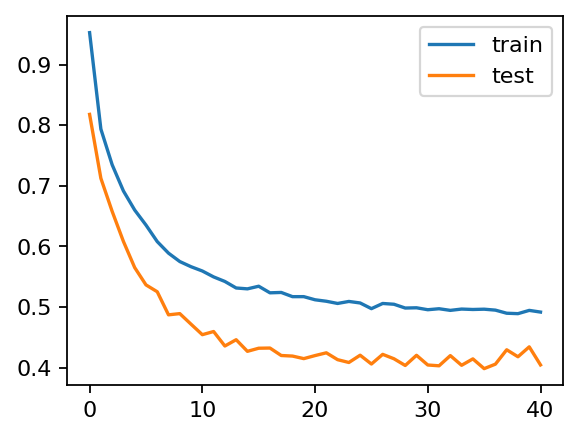

In [12]:
from keras.callbacks import EarlyStopping


def buscar_mejor_dropout_l2(rates, epochs=50, batch_size=512, patience=5, verbose=0):

    historiales = {}
    mejor_modelo = None
    mejor_hist = None
    mejor_rate = None
    mejor_val_loss = float('inf')

    for rate in rates:
        print(f'>>> Entrenando con Dropout = {rate}')
        #1. Definicion del modelo
        m = models.Sequential([
            layers.Input(shape=(10000,)),
            layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
            layers.Dropout(rate),
            layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
            layers.Dropout(rate),
            layers.Dense(1, activation='sigmoid'),
        ])

        #2. Compilacion del modelo
        m.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

        # 3. Aplicacion de parada temprana
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=0,
        )

        # 4. Entrenamiento del modelo
        h = m.fit(x_training, y_training,
                  epochs=epochs, batch_size=batch_size,
                  validation_data=(x_val, y_val),
                  callbacks=[early_stop],
                  verbose=verbose)
        historiales[rate] = h

        val_loss_min = min(h.history['val_loss'])
        if val_loss_min < mejor_val_loss:
            mejor_val_loss = val_loss_min
            mejor_modelo   = m
            mejor_hist     = h
            mejor_rate     = rate

    print('\nResultados de la búsqueda:')
    print(f'{"Dropout":>10} {"val_loss_min":>14} {"época_óptima":>14} {"épocas_corridas":>16} {"val_acc_max":>13}')
    print('-' * 75)
    for rate, h in historiales.items():
        vmin     = min(h.history['val_loss'])
        epoca    = h.history['val_loss'].index(vmin) + 1
        n_epocas = len(h.history['val_loss'])
        acc_max  = max(h.history['val_accuracy'])
        flag     = '  <-- mejor' if rate == mejor_rate else ''
        print(f'{rate:>10.2f} {vmin:>14.4f} {epoca:>14d} {n_epocas:>16d} {acc_max:>13.4f}{flag}')

    return mejor_modelo, mejor_hist, mejor_rate, historiales


tasas_candidatas = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
modelo_best_dp, hist_best_dp, mejor_rate, historiales_dp = buscar_mejor_dropout_l2(
    tasas_candidatas, epochs=50, patience=5, verbose=0)

print(f'\nMejor tasa de Dropout encontrada: {mejor_rate}')
print('Los pesos del modelo retornado corresponden a la mejor época (restore_best_weights=True),')
print('por lo que `modelo_best_dp` está listo para evaluar su aplicabilidad sobre el conjunto de prueba.')

# 5. Evaluacion del modelo
evaluate(modelo_best_dp, hist_best_dp)

Las curvas de train_loss y val_loss descienden de forma sostenida y terminan prácticamente superpuestas (~0.40), sin que la pérdida de validación vuelva a subir. La brecha entre ambas se cierra a partir de la época ~10, lo que indica que el modelo ya no sobre-ajusta y aprende patrones generales en lugar de memorizar el conjunto de entrenamiento. EarlyStopping detuvo el entrenamiento cerca de la mejor época, justo cuando las mejoras se estancaron, y restauró los pesos del mejor modelo ajustado para esta combinación.

## Conclusiones

A lo largo del notebook se entrenaron **cuatro variantes** de la misma arquitectura (16-16-1) sobre el dataset IMDB, manteniendo idénticos el optimizador y el `batch_size` para que la única variable controlada fuera la **estrategia de regularización**:

1. **Modelo original (sin regularización).** Llega a `train_acc ≈ 0.95` y `train_loss ≈ 0.0002`, pero su `val_loss` toca su mínimo en la época ~4 y luego sube hasta ~1.13 → **sobre-ajuste evidente**: el modelo memoriza los datos de entrenamiento y deja de generalizar.

2. **Modelo con L2 (λ = 0.01).** Al penalizar la magnitud de los pesos, el `train_loss` se queda en ~0.12 (no puede memorizar) y la `val_loss` final cae a la mitad (~0.55). El sobre-ajuste **se reduce**, pero no desaparece.

3. **Modelo con Dropout — primero fijo y luego optimizado.** Partiendo de un `Dropout(0.5)` arbitrario, se implementó una **búsqueda en grilla** (`buscar_mejor_dropout`) que prueba varias tasas (`[0.2, 0.3, …, 0.7]`) y, gracias a **`EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)`**, devuelve directamente el modelo con los **pesos de la mejor época**. Las curvas de `train` y `val` quedan **mucho más cerca** entre sí y la búsqueda permite quedarse, de manera reproducible, con la tasa que minimiza `val_loss`.

4. **Modelo combinado L2 + Dropout (mejor configuración).** En la Etapa 6 se replicó la misma búsqueda en grilla pero sobre la arquitectura con **L2(0.01) + Dropout(p)**, también con `EarlyStopping`. El resultado es el modelo que combina las dos formas de penalización con la **mejor tasa de Dropout** encontrada (`mejor_rate`) y los **mejores pesos** restaurados automáticamente. Es donde típicamente se observa la **menor brecha** entre `train_loss` y `val_loss`, es decir, el modelo que **mejor generaliza** de los cuatro.



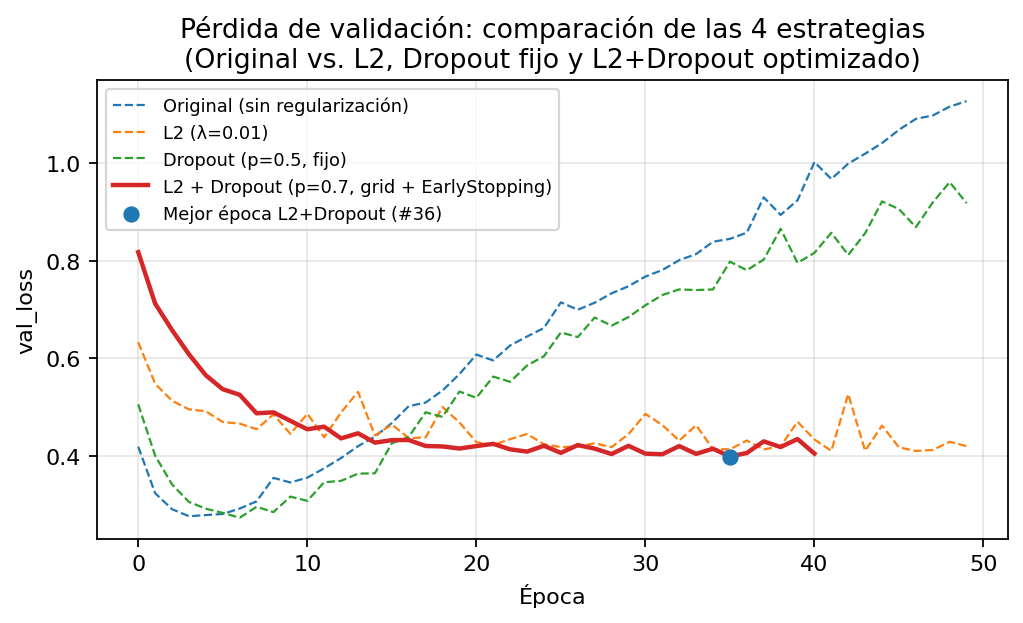

In [13]:
# Comparación final de las cuatro estrategias en val_loss.
# Nota: la curva de "L2 + Dropout" puede ser más corta que las demás porque
# en su entrenamiento se usó EarlyStopping (se detiene al dejar de mejorar).
plt.figure(figsize=(6.5, 4), dpi=160)

plt.plot(history.history['val_loss'],
         label='Original (sin regularización)',
         linestyle='--', linewidth=1.0)
plt.plot(history_l2.history['val_loss'],
         label='L2 (λ=0.01)',
         linestyle='--', linewidth=1.0)
plt.plot(history_dp.history['val_loss'],
         label='Dropout (p=0.5, fijo)',
         linestyle='--', linewidth=1.0)
plt.plot(hist_best_dp.history['val_loss'],
         label=f'L2 + Dropout (p={mejor_rate}, grid + EarlyStopping)',
         linestyle='-', linewidth=2.0)

# Marca la mejor época del modelo combinado (la que restauró EarlyStopping).
mejor_epoca = hist_best_dp.history['val_loss'].index(min(hist_best_dp.history['val_loss']))
plt.scatter([mejor_epoca], [min(hist_best_dp.history['val_loss'])],
            zorder=5, s=40, label=f'Mejor época L2+Dropout (#{mejor_epoca + 1})')

plt.xlabel('Época')
plt.ylabel('val_loss')
plt.title('Pérdida de validación: comparación de las 4 estrategias\n'
          '(Original vs. L2, Dropout fijo y L2+Dropout optimizado)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Lecciones generales

- La **regularización** (L2, Dropout o ambas) reduce sistemáticamente el sobre-ajuste respecto al modelo base, a costa de un `train_loss` más alto.
- **No basta con elegir una tasa de Dropout "por defecto"**: una pequeña búsqueda en grilla sobre `p` cambia de manera notable la `val_loss` mínima y, por tanto, la calidad del modelo final.
- **`EarlyStopping(restore_best_weights=True)`** es clave en este flujo: hace que la búsqueda sea más rápida (corta entrenamientos que ya no mejoran) y garantiza que los modelos comparados estén siempre en su **mejor punto**, no en la última época.
- La **combinación L2 + Dropout**, ajustada con grid search y EarlyStopping, ofrece el mejor compromiso entre capacidad de aprendizaje y generalización en este problema.